### [Time Series Secrets: Decomposition of a Time Series](https://medium.com/code-applied/time-series-secrets-decomposition-of-a-time-series-af754db07d79)

> A Time Series is a set measurements collected about a given subject during a period of time.

*Time series decomposition* is the process of breaking down a time series into components. These components are:

- **Trend:** The long-term direction of the series (upward, downward, or stable).
- **Seasonality:** Repeating patterns within a fixed period (e.g., yearly, quarterly, monthly).
- **Cyclical:** Patterns with duration longer than seasonality.
- **Residual (or Irregular):** Random, unpredictable fluctuations (the “noise” in your data).

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Data wrangling
import pandas as pd
import numpy as np

# Plot
import matplotlib.pyplot as plt

# Time Series Analysis and decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Metrics
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
# Generate a sample time series (you'd replace this with your actual data)
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2024-01-01', freq='M')
trend = np.linspace(100, 200, len(dates))
seasonal = 5 * np.sin(2 * np.pi * np.arange(len(dates)) / 12)
residual = np.random.normal(0, 5, len(dates))
time_series = trend + seasonal + residual

df = pd.DataFrame({'Date': dates, 'Value': time_series})
df.set_index('Date', inplace=True)
df.head(10)

,Value
Date,
2020-01-31,102.483571
2020-02-29,103.936338
2020-03-31,111.823889
2020-04-30,118.998128
2020-05-31,111.669998
2020-06-30,111.967613
2020-07-31,120.662022
2020-08-31,116.230791
2020-09-30,110.343778


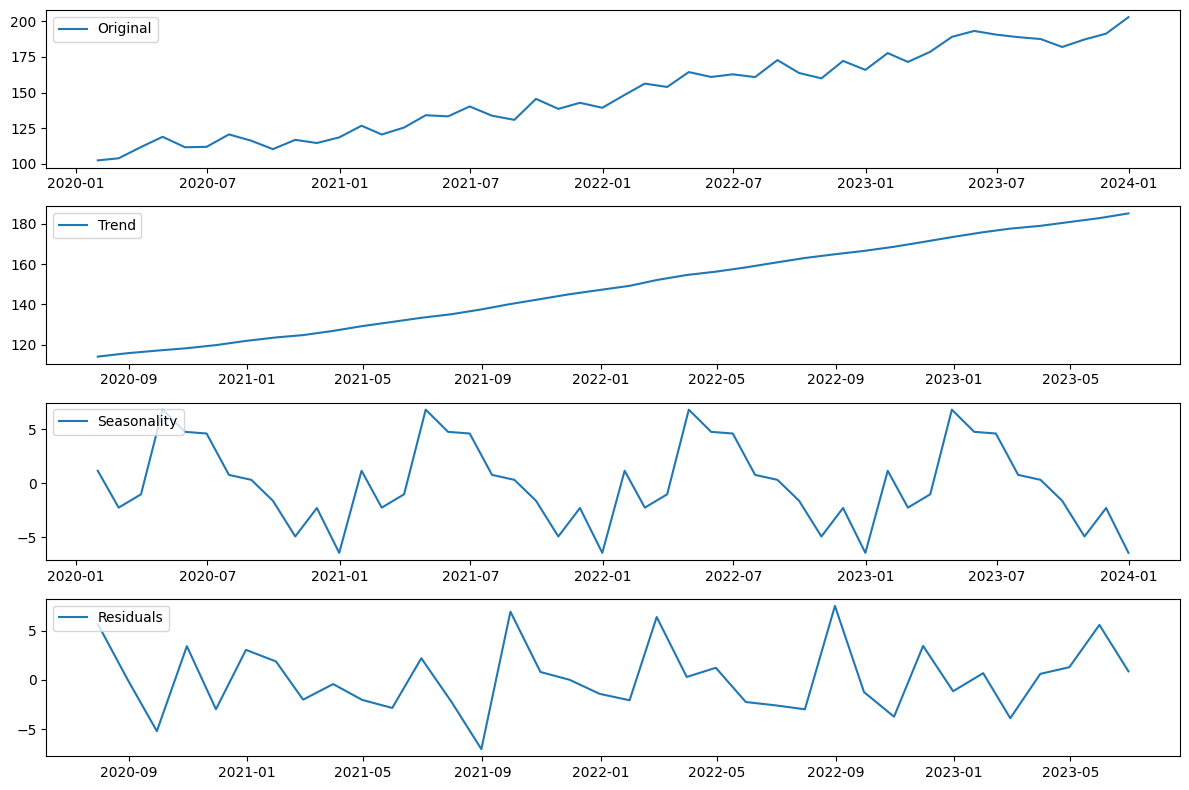

In [3]:
# Time Series Decomposition
# Monthly data with yearly seasonality
decomposition = seasonal_decompose(df['Value'], model='additive', period=12)


# Visualize the decomposed components
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df['Value'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [4]:
# Forecasting
train = df['2020-01-01':'2022-12-31']
test = df['2023-01-01':]

# Forecasting without decomposition (using Exponential Smoothing)
model_no_decomp = ExponentialSmoothing(train['Value'], seasonal_periods=12).fit()
predictions_no_decomp = model_no_decomp.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [5]:
mape_no_decomp = mean_absolute_percentage_error(test['Value'], predictions_no_decomp)
print(f"MAPE without decomposition: {mape_no_decomp}")

MAPE without decomposition: 0.10466853839307787


In [6]:
# Forecasting with additive decomposition
model_decomp = ExponentialSmoothing(train['Value'],
                                    seasonal_periods=12,
                                    trend='add',
                                    seasonal='add').fit()
predictions_decomp = model_decomp.forecast(len(test))

# Evaluate forecasting accuracy (MSE)
mape_decomp = mean_absolute_percentage_error(test['Value'], predictions_decomp)
print(f'MAPE with decomposition: {mape_decomp}')

MAPE with decomposition: 0.02503504409754662


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


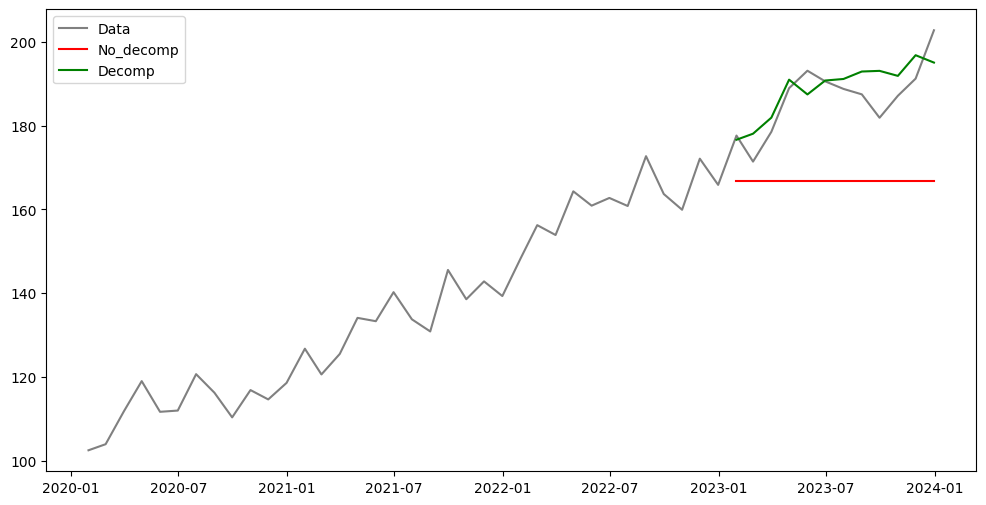

In [7]:
# Plotting the forecasts
plt.figure(figsize=(12, 6))
plt.plot(df['Value'], label='Data', color='gray')
plt.plot(predictions_no_decomp, label='No_decomp', color='red')
plt.plot(predictions_decomp, label='Decomp', color='green')
plt.legend()